In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

In [ ]:
# Constants / Configs
POSITION_MASTER = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
PLAYERS_NUMERIC_COLUMNS = ['form', 'points_per_game', 'ep_next', 'influence', 'creativity', 'threat', 'ict_index', 
                           'value_form', 'value_season', 'selected_by_percent', 'expected_goals', 'expected_assists', 
                           'expected_goal_involvements', 'expected_goals_conceded']
PLAYERS_NORMALIZATION_COLUMNS = ['points_per_game', 'ep_next', 'fdr', 'ict_index', 'chance_of_playing_next_round']
WEIGHTS = {
  'points_per_game': 0.3,
  'ep_next': 0.25,
  'fdr': 0.2,
  'ict_index': 0.15,
  'chance_of_playing_next_round': 0.1,
}

In [5]:
# Get Next Gameweek
bootstrap_response = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/')
bootstrap_response.raise_for_status()
bootstrap_data = bootstrap_response.json()
events = bootstrap_data["events"]

next_gw_title: str | None = None
next_gw_id: int | None = None

for event in events:
  if event["is_next"]:
    next_gw_id = event["id"]
    next_gw_title = event["name"]
    break

# The upcoming GW we are predicting for
# Sheet was fetched before this GW was played
GAMEWEEK = f'GW{next_gw_id}'

In [6]:
# Load Data.
players_df = pd.read_excel('./data/players_master.xlsx', sheet_name=GAMEWEEK)
teams_df = pd.read_excel('./data/teams_master.xlsx', sheet_name=GAMEWEEK)
fixtures_df = pd.read_excel('./data/fixtures_master.xlsx', sheet_name=GAMEWEEK)

In [7]:
# Computations

players_df['full_name'] = players_df['first_name'] + ' ' + players_df['second_name']
players_df['position'] = players_df['element_type'].map(POSITION_MASTER)
players_df['team_name'] = players_df['team'].map(dict(zip(teams_df['id'], teams_df['name'])))

# Using `errors='coerce'` to enter NaN for invalid values without raising exceptions.
for col in PLAYERS_NUMERIC_COLUMNS:
  players_df[col] = pd.to_numeric(players_df[col], errors='coerce')

# FPL passes values into 'chance_of_playing_next_round' only during issues example 50, 75.
# So missing value means player is fit to play. So replacing NA with 100 for calculations.
players_df['chance_of_playing_next_round'] = players_df['chance_of_playing_next_round'].fillna(100)
players_df['ep_next'] = players_df['ep_next'].fillna(0)
players_df = players_df[players_df['status'].isin(['a', 'i', 'd'])]

# FPL sends cost (euro) multiplied for 10 by default.
players_df['cost'] = players_df['now_cost'] / 10
players_df['points_per_euro'] = players_df['total_points'] / players_df['cost']

home = fixtures_df[['team_h', 'team_h_difficulty']].rename(columns={'team_h': 'team_id', 'team_h_difficulty': 'fdr'})
away = fixtures_df[['team_a', 'team_a_difficulty']].rename(columns={'team_a': 'team_id', 'team_a_difficulty': 'fdr'})
fdr_df = pd.concat([home, away])
players_df['fdr'] = players_df['team'].map(dict(zip(fdr_df['team_id'], fdr_df['fdr'])))

for col in PLAYERS_NORMALIZATION_COLUMNS:
  # FDR (Difficulty) Low = Easy (Good), High = Difficult (Bad)
  # Inverting normalization for FDR as we want HIGH = Good, LOW = Bad.
  if col == 'fdr':
    players_df[f'{col}_norm'] = 1 - ((players_df[col] - players_df[col].min()) / (players_df[col].max() - players_df[col].min()))
  else:
    players_df[f'{col}_norm'] = (players_df[col] - players_df[col].min()) / (players_df[col].max() - players_df[col].min())

# Creating a fresh contiguous copy of the DataFrame in memory as pandas internally fragments memory.
players_df = players_df.copy()

players_df['next_gw_score'] = sum([players_df[f'{col}_norm'] * value for col, value in WEIGHTS.items()])

# Players who actually play. (Score points)
active_players = players_df[players_df['total_points'] > 0]

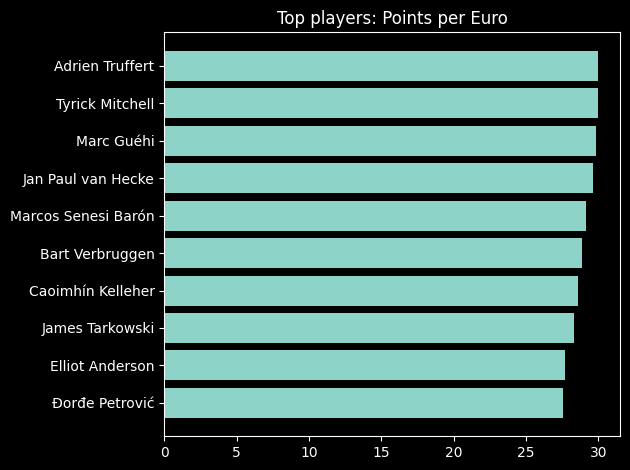

In [8]:
# Visualizations
plt.style.use('dark_background')

fig, ax = plt.subplots()
top_10_by_value = players_df.sort_values(by='points_per_euro', ascending=False).head(10).sort_values(by='points_per_euro', ascending=True)
ax.barh(top_10_by_value['full_name'], top_10_by_value['points_per_euro'])
ax.set_title('Top players: Points per Euro')
plt.tight_layout()
plt.show()

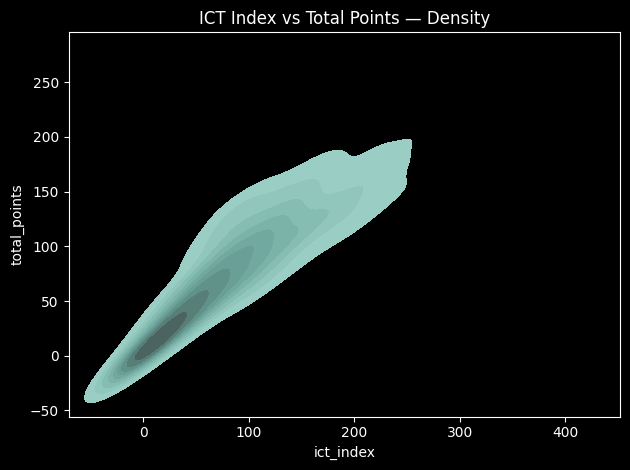

In [9]:
fig, ax = plt.subplots()
sns.kdeplot(data=active_players, x='ict_index', y='total_points', fill=True, ax=ax)
ax.set_title('ICT Index vs Total Points — Density')
plt.tight_layout()
plt.show()

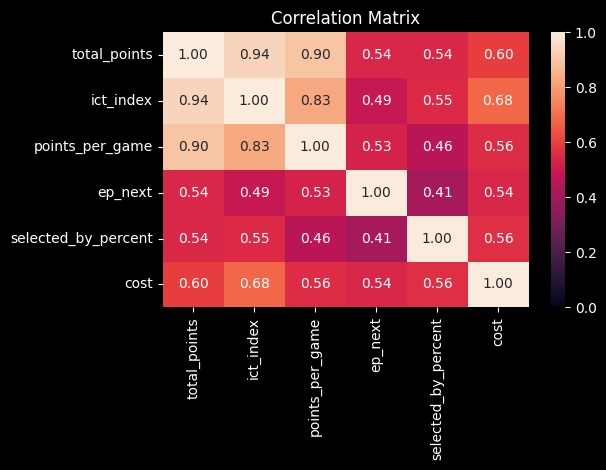

In [10]:
corr_cols = ['total_points', 'ict_index', 'points_per_game', 'ep_next', 'selected_by_percent', 'cost']
corr_matrix = players_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
rec_cols = ['full_name', 'team_name', 'position', 'cost', 'fdr', 'next_gw_score']
recommendations = players_df.sort_values(by=['position', 'next_gw_score'], ascending=False).groupby('position').head(10)[rec_cols]

for _, pos in POSITION_MASTER.items():
  temp_df = recommendations[recommendations['position'] == pos]
  display(
    temp_df.sort_values(by='next_gw_score', ascending=False)
    .style
    .set_caption(pos)
    .background_gradient(subset=['next_gw_score'], cmap='Greens')
    .format({'next_gw_score': '{:.2f}', 'cost': '£{:.1f}'})
  )

,full_name,team_name,position,cost,fdr,next_gw_score
0,David Raya Martín,Arsenal,GKP,£6.0,2,0.76
539,Robin Roefs,Sunderland,GKP,£5.0,2,0.67
201,Walter Benítez,Crystal Palace,GKP,£4.5,3,0.66
541,Melker Ellborg,Sunderland,GKP,£4.5,2,0.66
389,Gianluigi Donnarumma,Man City,GKP,£5.5,3,0.64
476,Matz Sels,Nott'm Forest,GKP,£5.0,2,0.64
421,Senne Lammens,Man Utd,GKP,£5.0,2,0.63
228,Jordan Pickford,Everton,GKP,£5.5,3,0.63
354,Alisson Becker,Liverpool,GKP,£5.5,3,0.61
81,Caoimhín Kelleher,Brentford,GKP,£5.0,3,0.60


,full_name,team_name,position,cost,fdr,next_gw_score
3,Gabriel dos Santos Magalhães,Arsenal,DEF,£8.0,2,0.88
543,Nordi Mukiele,Sunderland,DEF,£5.5,2,0.71
360,Virgil van Dijk,Liverpool,DEF,£6.5,3,0.70
392,Nico O'Reilly,Man City,DEF,£6.5,3,0.69
393,Marc Guéhi,Man City,DEF,£6.0,3,0.69
509,Marcos Senesi Barón,Spurs,DEF,£6.0,3,0.68
231,James Tarkowski,Everton,DEF,£6.0,3,0.67
7,Riccardo Calafiori,Arsenal,DEF,£5.5,2,0.67
542,Daniel Ballard,Sunderland,DEF,£5.0,2,0.66
478,Neco Williams,Nott'm Forest,DEF,£5.0,2,0.66


,full_name,team_name,position,cost,fdr,next_gw_score
435,Bruno Borges Fernandes,Man Utd,MID,£12.0,2,0.99
11,Bukayo Saka,Arsenal,MID,£9.5,2,0.81
489,Morgan Gibbs-White,Nott'm Forest,MID,£8.0,2,0.79
12,Declan Rice,Arsenal,MID,£7.5,2,0.77
436,Bryan Mbeumo,Man Utd,MID,£8.0,2,0.76
402,Antoine Semenyo,Man City,MID,£8.5,3,0.75
437,Matheus Santos Carneiro da Cunha,Man Utd,MID,£8.0,2,0.74
139,Morgan Rogers,Chelsea,MID,£7.5,3,0.68
155,Enzo Fernández,Chelsea,MID,£7.0,3,0.68
372,Dominik Szoboszlai,Liverpool,MID,£7.0,3,0.68


,full_name,team_name,position,cost,fdr,next_gw_score
416,Erling Haaland,Man City,FWD,£15.5,3,0.89
104,Igor Thiago Nascimento Rodrigues,Brentford,FWD,£8.0,3,0.70
163,João Pedro Junqueira de Jesus,Chelsea,FWD,£7.5,3,0.68
53,Ollie Watkins,Aston Villa,FWD,£8.0,3,0.67
24,Viktor Gyökeres,Arsenal,FWD,£7.5,2,0.66
499,Igor Jesus Maciel da Cruz,Nott'm Forest,FWD,£6.0,2,0.61
350,Dominic Calvert-Lewin,Leeds,FWD,£6.0,3,0.61
448,Benjamin Sesko,Man Utd,FWD,£7.0,2,0.60
562,Brian Brobbey,Sunderland,FWD,£6.0,2,0.60
25,Kai Havertz,Arsenal,FWD,£7.5,2,0.59
